In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [3]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [8]:
from pprint import pprint

In [10]:
pprint(arxiv.invoke("Attention iss all you need"))

('Published: 2024-07-22\n'
 "Title: Attention Is All You Need But You Don't Need All Of It For Inference "
 'of Large Language Models\n'
 'Authors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale '
 'Minervini\n'
 'Summary: The inference demand for LLMs has skyrocketed in recent months, and '
 'serving\n'
 'models with low latencies remains challenging due to the quadratic input '
 'length\n'
 'complexity of the attention layers. In this work, we investigate the effect '
 'of\n'
 'dropping MLP and attention layers at inference time o')


In [12]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [16]:
result=wiki.invoke("What is machine learning")

In [18]:
pprint(result)

('Page: Machine learning\n'
 'Summary: Machine learning (ML) is a field of study in artificial '
 'intelligence concerned with the development and study of statistical '
 'algorithms that can learn from data and generalise to unseen data, and thus '
 'perform tasks without explicit instructions. Within a subdiscipline in '
 'machine learning, advances in the field of deep learning have allowed neural '
 'networks, a class of statistical algorithms, to surpass many previous '
 'machine learning approaches in performance.\n'
 'ML fi')


In [21]:
from dotenv import load_dotenv
load_dotenv()

import os

In [22]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [24]:
tavily.invoke("Provide me the recent AI news for September 2025")

[{'title': 'AI News September 6 2025, The Pulse And The Pattern',
  'url': 'https://binaryverseai.com/ai-news-september-6-2025/',
  'content': '## 15. Broadcom Pops On A 10B Mystery AI Order\n\nBroadcom’s quarter beat on revenue and earnings, then a new 10 billion dollar custom accelerator order dropped into guidance. The stock jumped. AI revenue climbed fast and management lifted the outlook again. A fourth hyperscale customer is buying XPUs at production scale with shipments ramping in 2026. The networking business that stitches clusters together is growing with it. The VMware software piece keeps cash flow strong. [...] Salesforce grew revenue and margins, expanded its buyback, and still cut 4,000 roles, mostly in support. AI agents now handle about one million customer conversations. Fewer front line roles and more automation fit the strategy that leadership has described for months. The stock dipped on softer guidance as enterprise budgets tighten. This is the shape of the transit

In [25]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [27]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

llm_with_tools=llm.bind_tools(tools)

In [30]:
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (drsn1kqtp)
 Call ID: drsn1kqtp
  Args:
    query: recent AI news


In [31]:
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '42s5wcp7w',
  'type': 'tool_call'}]

In [33]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

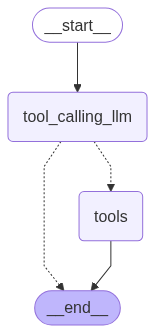

In [40]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    print("---- ",state['messages'])
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [43]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

----  [HumanMessage(content='1706.03762', additional_kwargs={}, response_metadata={}, id='b587c4bd-da3b-40f9-9401-a682793fb50e')]
================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (5h609jfx5)
 Call ID: 5h609jfx5
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, base


In [38]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for september 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for september 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (nvd5sx55f)
 Call ID: nvd5sx55f
  Args:
    query: top 10 AI news September 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI by AI Weekly Top 5: September 1 – 7, 2025 - Champaign Magazine", "url": "https://champaignmagazine.com/2025/09/07/ai-by-ai-weekly-top-5-september-1-7-2025/", "content": "Date: September 5, 2025\n Context: OpenAI and Meta updated their AI chatbots to better handle teen mental health crises. OpenAI added parental controls and distress alerts, while Meta blocked discussions of self-harm and directed users to expert resources. This follows a lawsuit over a teen suicide linked to ChatGPT.\n Significance: Reflects growing scrutin